# Data Evaluation: User Study

## 0. Setup

In [37]:
import pandas as pd
import matplotlib as mpl
%matplotlib inline

data_df = pd.read_csv('../eval-toolchain/eval-data.csv')
data_df

,participant,p_id,date,group,s_issues_miro,s_issues_pixie,s_issues_correct_miro,s_issues_correct_pixie,p_answered_miro,p_answered_pixie,p_answered_correct_miro,p_answered_correct_pixie
0,2,PA40344,2026-06-29,AP,5.0,3.0,NaN,NaN,6.0,6.0,NaN,NaN
1,5,MA7125,2026-06-30,AM,2.0,3.0,NaN,NaN,4.0,3.0,NaN,NaN
2,21,MA26593,2026-07-07,AM,1.0,0.0,NaN,NaN,3.0,4.0,NaN,NaN
3,20,PB3394,2026-07-06,BP,2.0,0.0,NaN,NaN,6.0,6.0,NaN,NaN
4,14,PA4076,2026-07-02,AP,2.0,5.0,NaN,NaN,6.0,4.0,NaN,NaN
5,16,PB46220,2026-07-02,BP,4.0,2.0,NaN,NaN,5.0,3.0,NaN,NaN
6,6,PA45003,2026-06-30,AP,2.0,1.0,NaN,NaN,3.0,4.0,NaN,NaN
7,4,PB54700,2026-06-30,BP,3.0,2.0,NaN,NaN,6.0,3.0,NaN,NaN
8,7,MB24145,2026-06-30,BM,3.0,2.0,NaN,NaN,1.0,4.0,NaN,NaN
9,15,MB10509,2026-07-02,BM,3.0,1.0,NaN,NaN,3.0,5.0,NaN,NaN


## 1. Data Exploration

### Total Numbers of Issues/Answered Questions

includes incorrect answers

In [38]:
total_counts_data_cols = [
    's_issues_miro',
    's_issues_pixie',
    'p_answered_miro',
    'p_answered_pixie',
]
total_counts_solvability = [
    's_issues_miro',
    's_issues_pixie',

]
total_counts_pacing = [
    'p_answered_miro',
    'p_answered_pixie',
]
#num_data_df = data_df[num_data_cols]
#num_data_df.index = data_df['p_id']
#plot = num_data_df.plot.pie(subplots=True, figsize=(5, 5))

#### Distribution of Total Number of Answered Questions Across Participants By Tool

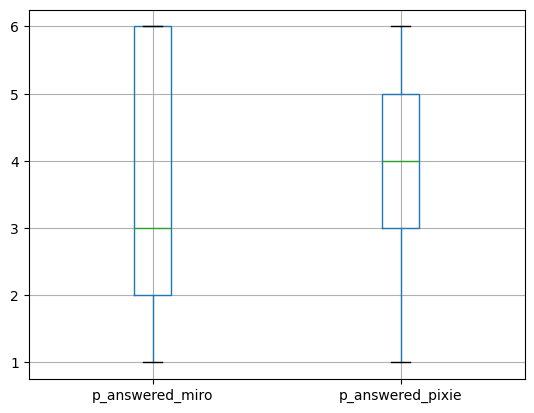

In [39]:
total_pacing_boxplot = data_df.boxplot(column=total_counts_pacing)

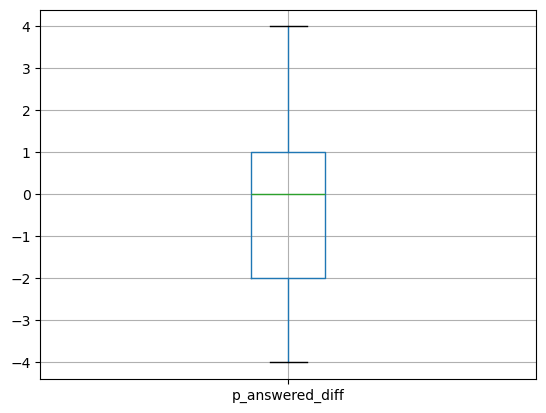

In [40]:
data_df['p_answered_diff'] = data_df['p_answered_pixie'] - data_df['p_answered_miro']
pacing_diff = data_df.boxplot(column=['p_answered_diff'])

### Timeseries

In [41]:
timeseries_data_df = pd.read_csv('../eval-toolchain/time_series/all.csv')
timeseries_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,LA_3,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,LA_3,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,LA_3,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,LA_3,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,LA_3,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...,...
731,MB67500,BM,pacing_miro,LA_2,15:39:55,Q2A,section A faster on average,250
732,MB67500,BM,pacing_miro,LA_2,15:40:25,Q5A,"increases: 16-18, 21-2 to 21-3",280
733,MB67500,BM,pacing_miro,LA_2,15:40:45,rem,"rk: need boss key, but same result",300
734,MB67500,BM,pacing_miro,LA_2,15:41:07,Q4A,miniboss ~~21-3~~ 15,322


#### Timeseries: Answers

In [42]:
answers_data_df = timeseries_data_df[timeseries_data_df['tag'].isin(['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A'])]
answers_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
11,PA40344,AP,pacing_pixie,LA_1,01:43:52,Q1A,q1 not steadily increasing,41
12,PA40344,AP,pacing_pixie,LA_1,01:45:10,Q2A,b shorter than a,119
13,PA40344,AP,pacing_pixie,LA_1,01:45:36,Q3A,more enemies in b than c,145
14,PA40344,AP,pacing_pixie,LA_1,01:46:51,Q4A,miniboss 18 or 7,220
15,PA40344,AP,pacing_pixie,LA_1,01:47:17,Q5A,9-3 to 5 sharpest increase,246
...,...,...,...,...,...,...,...,...
723,MB67500,BM,pacing_pixie,LA_1,15:45:47,Q5A,increase: 9-1 to 9,227
724,MB67500,BM,pacing_pixie,LA_1,15:46:25,Q5A,"9-3 only one enemy after 4 before, also 11-15",265
731,MB67500,BM,pacing_miro,LA_2,15:39:55,Q2A,section A faster on average,250
732,MB67500,BM,pacing_miro,LA_2,15:40:25,Q5A,"increases: 16-18, 21-2 to 21-3",280


##### Distribution of Answer Events Across Time

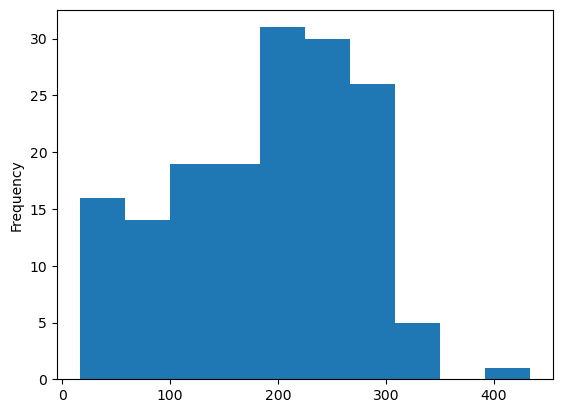

In [43]:
ax3 = answers_data_df['timedelta'].plot.hist()